**Predicting Bike Sharing Demand**

## Problem & Dataset Definition

Bike-sharing systems need to anticipate changes in customer demand to ensure that bicycles are available when and where they are needed. The objective of this project is to develop a regression model that predicts the total number of hourly bike rentals (`count`) using weather, calendar, and time-related information.

The dataset is the Bike Sharing Demand dataset from Kaggle and contains 10,886 hourly observations collected over a two-year period. It includes variables describing weather conditions, temperature, humidity, season, holidays, working days, and bike rental activity.

The target variable is `count`, which represents the total number of bikes rented during a given hour. Since `count` is numerical, this is a regression problem. *

This project requires Python 3.7 or above:

In [45]:
import sys

assert sys.version_info >= (3, 7)

It also requires Scikit-Learn ≥ 1.0.1:

In [46]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

# Getting the Data
The Bike Sharing Demand dataset is loaded below using pandas for initial exploration and preprocessing.

## Loading the Data

In [47]:
import pandas as pd
bike = pd.read_csv("/kaggle/input/competitions/bike-sharing-demand/train.csv")

## Looking at the Data Structure

In [48]:
bike.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [49]:
bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [50]:
bike["weather"].value_counts()

weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64

In [51]:
bike.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


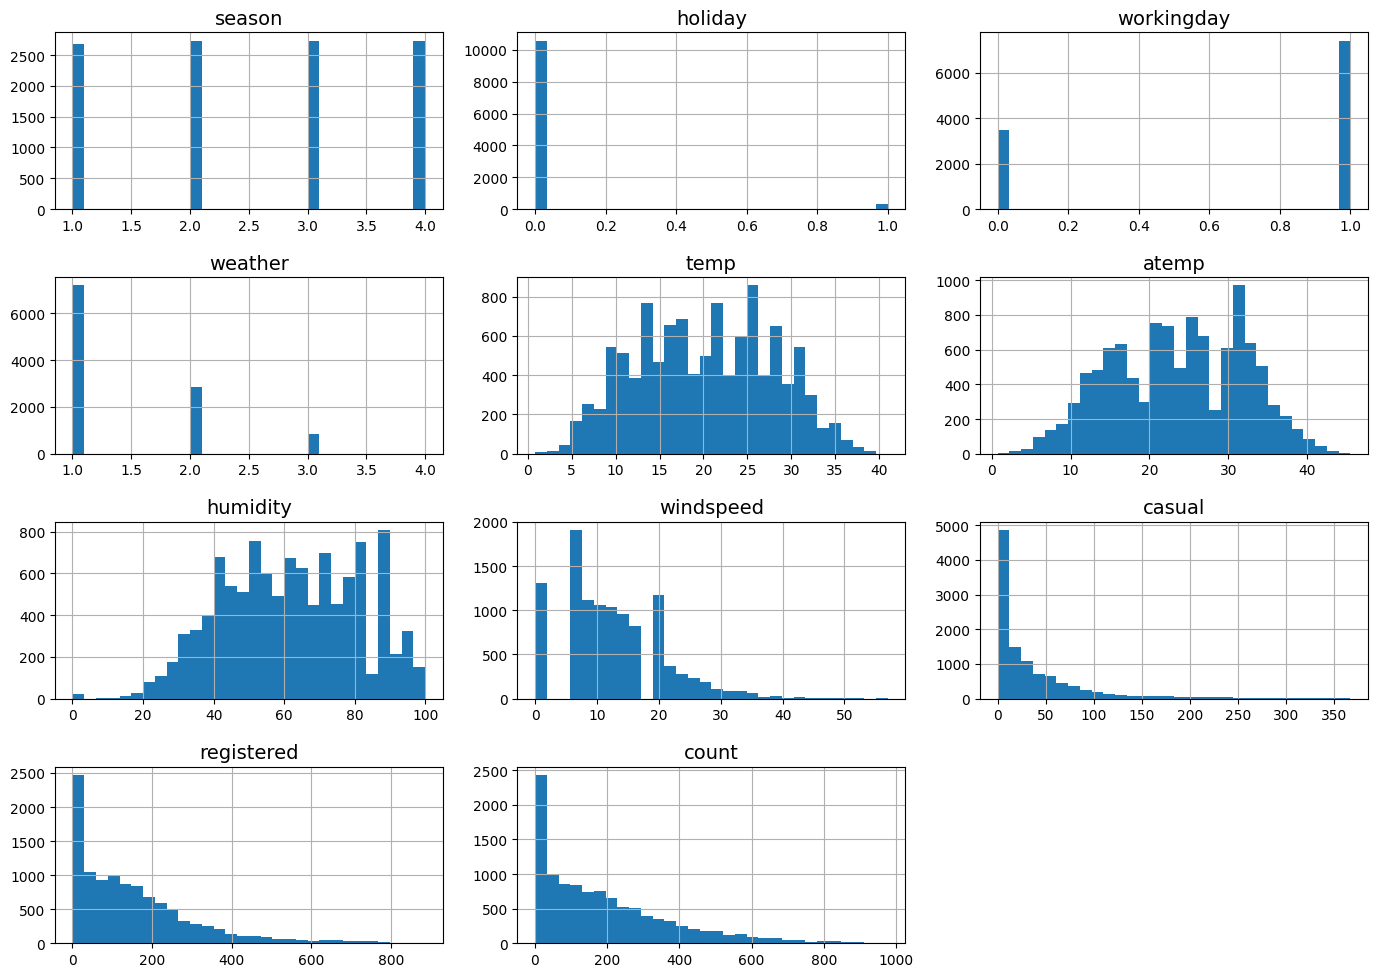

In [52]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

bike.hist(bins=30, figsize=(14, 10))
plt.tight_layout()
plt.show()

## Creating a Test Set

The dataset will be divided into training and test sets so that model performance can be evaluated on unseen observations.

Because the observations are time-ordered, the earlier 80% of observations will be used for training and the most recent 20% will be reserved for testing.

In [53]:
bike["datetime"] = pd.to_datetime(bike["datetime"])
bike = bike.sort_values("datetime").reset_index(drop=True)

split_index = int(len(bike) * 0.8)

train_set = bike.iloc[:split_index].copy()
test_set = bike.iloc[split_index:].copy()

print("Training set:", len(train_set))
print("Test set:", len(test_set))

Training set: 8708
Test set: 2178


# Discover and Visualize the Data to Gain Insights

This section explores patterns in bike rental demand and its relationship with time, weather, and working-day characteristics. These visualizations help identify variables that may be useful for predicting total bike rental demand.

## Looking for Correlations

In [54]:
corr_matrix = train_set.corr(numeric_only=True)

In [55]:
corr_matrix["count"].sort_values(ascending=False)

count         1.000000
registered    0.968785
casual        0.708575
temp          0.431737
atemp         0.428493
season        0.113750
windspeed     0.101773
workingday    0.004812
holiday      -0.006979
weather      -0.142872
humidity     -0.327362
Name: count, dtype: float64

Correlation Analysis: registered and casual have very strong correlations with count; however, they are not valid predictors because count is defined as the sum of registered and casual rentals. Including them would therefore introduce target leakage, so they will be removed before model training. Among the remaining predictors, temperature and apparent temperature show the strongest positive linear relationships with bike rental demand.

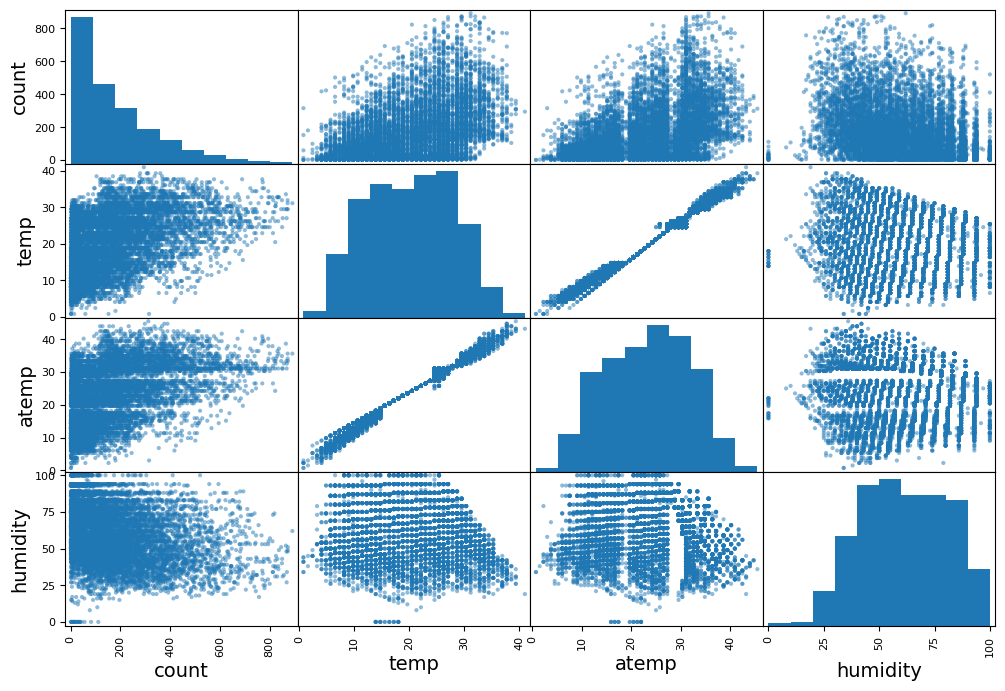

In [56]:
from pandas.plotting import scatter_matrix

attributes = ["count", "temp", "atemp", "humidity"]

scatter_matrix(train_set[attributes], figsize=(12, 8))
plt.show()

The scatter matrix shows that temperature and apparent temperature have positive relationships with bike rental demand, while humidity has a negative relationship with demand. Temperature and apparent temperature are also strongly related to each other, suggesting that they contain similar information.

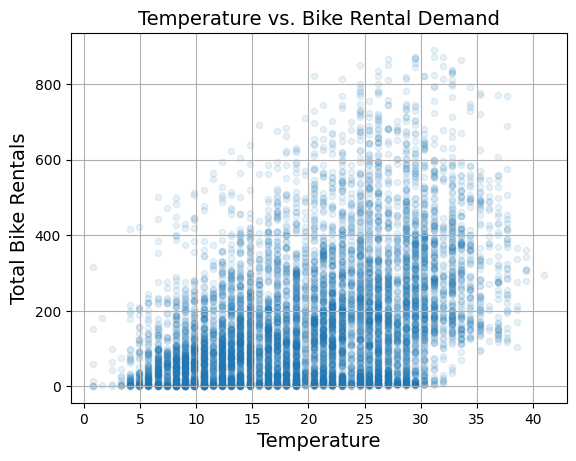

In [57]:
train_set.plot(
    kind="scatter",
    x="temp",
    y="count",
    alpha=0.1,
    grid=True
)
plt.xlabel("Temperature")
plt.ylabel("Total Bike Rentals")
plt.title("Temperature vs. Bike Rental Demand")
plt.show()

Temperature vs. Demand: Bike rental demand generally increases as temperature rises, although there is substantial variation at each temperature level. This suggests that temperature is a useful predictor, but other factors also influence rental demand.

## Feature Engineering: Time-Based Features

In [58]:
# Create useful time-based features from datetime
train_set["hour"] = train_set["datetime"].dt.hour
train_set["dayofweek"] = train_set["datetime"].dt.dayofweek
train_set["month"] = train_set["datetime"].dt.month
train_set["year"] = train_set["datetime"].dt.year

test_set["hour"] = test_set["datetime"].dt.hour
test_set["dayofweek"] = test_set["datetime"].dt.dayofweek
test_set["month"] = test_set["datetime"].dt.month
test_set["year"] = test_set["datetime"].dt.year

Time-based feature engineering: The original datetime variable contains potentially useful information that a regression model cannot directly use in its raw form. Hour, day of week, month, and year are extracted to capture hourly, weekly, seasonal, and longer-term patterns in bike rental demand.

In [59]:
corr_matrix = train_set.corr(numeric_only=True)

corr_matrix["count"].drop(
    ["count", "casual", "registered"]
).sort_values(ascending=False)

temp          0.431737
atemp         0.428493
hour          0.401074
year          0.232843
month         0.117770
season        0.113750
windspeed     0.101773
dayofweek     0.005507
workingday    0.004812
holiday      -0.006979
weather      -0.142872
humidity     -0.327362
Name: count, dtype: float64

Correlation Analysis: Temperature, apparent temperature, and hour show the strongest positive linear relationships with bike rental demand, while humidity shows a moderate negative relationship. These correlations provide an initial indication of potentially useful predictors, but variables with low linear correlations are not automatically removed because they may still have nonlinear or categorical relationships with demand.

# Preparing the Data for Machine Learning Algorithms

Separate the predictor variables from the target variable (count). The casual and registered variables are excluded because they directly make up the target (count = casual + registered) and would cause target leakage. The original datetime column is also removed because relevant time features have already been extracted from it.

In [60]:
X_train = train_set.drop(
    columns=["count", "casual", "registered"]
)
y_train = train_set["count"].copy()

X_test = test_set.drop(
    columns=["count", "casual", "registered"]
)
y_test = test_set["count"].copy()

In [61]:
# Remove the original datetime column after extracting useful time features
X_train = X_train.drop(columns=["datetime"], errors="ignore")
X_test = X_test.drop(columns=["datetime"], errors="ignore")

In [62]:
print("X_train columns:", X_train.columns.tolist())
print("X_test columns:", X_test.columns.tolist())
print("Same columns:", X_train.columns.equals(X_test.columns))

X_train columns: ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'hour', 'dayofweek', 'month', 'year']
X_test columns: ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'hour', 'dayofweek', 'month', 'year']
Same columns: True


## Data Cleaning

In [63]:
X_train.isnull().sum()

season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
hour          0
dayofweek     0
month         0
year          0
dtype: int64

Missing Values: The training data was checked for missing values using isnull().sum(). No missing values were found in any of the predictor variables, so no imputation or removal of observations was required.

**Checking for Outliers**

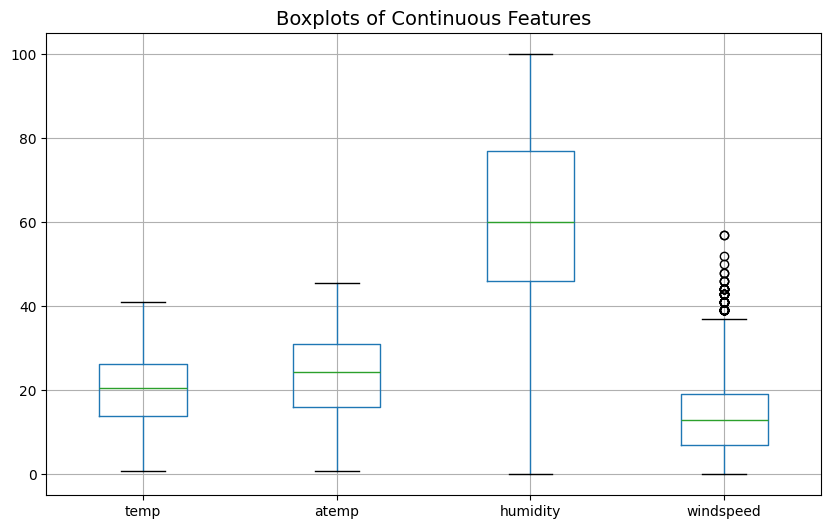

In [64]:
X_train[["temp", "atemp", "humidity", "windspeed"]].boxplot(figsize=(10, 6))
plt.title("Boxplots of Continuous Features")
plt.show()

Outlier Interpretation: The boxplots show several potential high-value outliers for windspeed, while temperature, apparent temperature, and humidity do not show clear outliers. The windspeed observations were retained because they fall within plausible weather conditions and may represent genuine variation rather than data-entry errors. Removing these observations could therefore discard useful information about bike rental demand under unusually windy conditions.

## Handling Categorical Attributes

In [65]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "season", "weather", "holiday", "workingday",
    "hour", "dayofweek", "month"
]

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoded_train = encoder.fit_transform(X_train[categorical_features])
encoded_test = encoder.transform(X_test[categorical_features])

encoder.get_feature_names_out(categorical_features)

array(['season_1', 'season_2', 'season_3', 'season_4', 'weather_1',
       'weather_2', 'weather_3', 'weather_4', 'holiday_0', 'holiday_1',
       'workingday_0', 'workingday_1', 'hour_0', 'hour_1', 'hour_2',
       'hour_3', 'hour_4', 'hour_5', 'hour_6', 'hour_7', 'hour_8',
       'hour_9', 'hour_10', 'hour_11', 'hour_12', 'hour_13', 'hour_14',
       'hour_15', 'hour_16', 'hour_17', 'hour_18', 'hour_19', 'hour_20',
       'hour_21', 'hour_22', 'hour_23', 'dayofweek_0', 'dayofweek_1',
       'dayofweek_2', 'dayofweek_3', 'dayofweek_4', 'dayofweek_5',
       'dayofweek_6', 'month_1', 'month_2', 'month_3', 'month_4',
       'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10',
       'month_11', 'month_12'], dtype=object)

One-hot encoding: One-hot encoding was applied to season, weather, holiday, working day, hour, day of week, and month because these variables represent categories rather than continuous numerical quantities. This prevents the regression model from assuming that their numerical codes have a continuous linear relationship with bike rental demand.

In [66]:
# Check the predictor variables that will be used by the model

X_train.columns

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'hour', 'dayofweek', 'month', 'year'],
      dtype='object')

## Building the Preprocessing Pipeline

In [67]:
# Build preprocessing pipelines for numerical and categorical features

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = [
    "temp", "atemp", "humidity", "windspeed", "year"
]

categorical_features = [
    "season", "weather", "holiday", "workingday",
    "hour", "dayofweek", "month"
]

numeric_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

preprocessing = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

In [68]:
# Fit the preprocessing steps using the training data and apply them to both sets

X_train_prepared = preprocessing.fit_transform(X_train)
X_test_prepared = preprocessing.transform(X_test)

print("Training data shape:", X_train_prepared.shape)
print("Test data shape:", X_test_prepared.shape)

Training data shape: (8708, 60)
Test data shape: (2178, 60)


Preprocessing Pipeline: Continuous numerical features were standardized using StandardScaler, while categorical features were transformed using one-hot encoding. The preprocessing pipeline was fitted only on the training data and then applied to the test data to avoid data leakage. After preprocessing, both datasets contain 60 predictor features.

In [69]:
preprocessing.get_feature_names_out()

array(['num__temp', 'num__atemp', 'num__humidity', 'num__windspeed',
       'num__year', 'cat__season_1', 'cat__season_2', 'cat__season_3',
       'cat__season_4', 'cat__weather_1', 'cat__weather_2',
       'cat__weather_3', 'cat__weather_4', 'cat__holiday_0',
       'cat__holiday_1', 'cat__workingday_0', 'cat__workingday_1',
       'cat__hour_0', 'cat__hour_1', 'cat__hour_2', 'cat__hour_3',
       'cat__hour_4', 'cat__hour_5', 'cat__hour_6', 'cat__hour_7',
       'cat__hour_8', 'cat__hour_9', 'cat__hour_10', 'cat__hour_11',
       'cat__hour_12', 'cat__hour_13', 'cat__hour_14', 'cat__hour_15',
       'cat__hour_16', 'cat__hour_17', 'cat__hour_18', 'cat__hour_19',
       'cat__hour_20', 'cat__hour_21', 'cat__hour_22', 'cat__hour_23',
       'cat__dayofweek_0', 'cat__dayofweek_1', 'cat__dayofweek_2',
       'cat__dayofweek_3', 'cat__dayofweek_4', 'cat__dayofweek_5',
       'cat__dayofweek_6', 'cat__month_1', 'cat__month_2', 'cat__month_3',
       'cat__month_4', 'cat__month_5', 'cat__mo

In [70]:
# Display the names of the features created by preprocessing

preprocessing.get_feature_names_out()

array(['num__temp', 'num__atemp', 'num__humidity', 'num__windspeed',
       'num__year', 'cat__season_1', 'cat__season_2', 'cat__season_3',
       'cat__season_4', 'cat__weather_1', 'cat__weather_2',
       'cat__weather_3', 'cat__weather_4', 'cat__holiday_0',
       'cat__holiday_1', 'cat__workingday_0', 'cat__workingday_1',
       'cat__hour_0', 'cat__hour_1', 'cat__hour_2', 'cat__hour_3',
       'cat__hour_4', 'cat__hour_5', 'cat__hour_6', 'cat__hour_7',
       'cat__hour_8', 'cat__hour_9', 'cat__hour_10', 'cat__hour_11',
       'cat__hour_12', 'cat__hour_13', 'cat__hour_14', 'cat__hour_15',
       'cat__hour_16', 'cat__hour_17', 'cat__hour_18', 'cat__hour_19',
       'cat__hour_20', 'cat__hour_21', 'cat__hour_22', 'cat__hour_23',
       'cat__dayofweek_0', 'cat__dayofweek_1', 'cat__dayofweek_2',
       'cat__dayofweek_3', 'cat__dayofweek_4', 'cat__dayofweek_5',
       'cat__dayofweek_6', 'cat__month_1', 'cat__month_2', 'cat__month_3',
       'cat__month_4', 'cat__month_5', 'cat__mo

Preprocessing Summary: Three main preprocessing and feature engineering methods were applied: time-based feature engineering to extract year, month, day of week, and hour from datetime; one-hot encoding to convert categorical variables into numerical features; and standard scaling to place continuous numerical variables on a comparable scale.

## Model Training and Evaluation

I will first train a Linear Regression model as a baseline. Model performance will be evaluated using RMSE, MAE, and R².

### Linear Regression Baseline

In [71]:
from sklearn.linear_model import LinearRegression

# Train a Linear Regression model as a baseline
lin_reg = LinearRegression()
lin_reg.fit(X_train_prepared, y_train)

LinearRegression()

In [72]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Make predictions on the test data
y_pred = lin_reg.predict(X_test_prepared)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

RMSE: 131.27140818026817
MAE: 98.38086598861535
R²: 0.6360556729187059


Linear Regression Results: The baseline Linear Regression model achieved an RMSE of 131.27, an MAE of 98.38, and an R² of 0.636 on the test set. This means the model explains approximately 63.6% of the variation in bike rental demand. These results provide a baseline for comparison with more flexible models that may better capture nonlinear relationships in the data.

# Random Forest Regression

In [73]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest model
forest_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_reg.fit(X_train_prepared, y_train)

RandomForestRegressor(random_state=42)

In [74]:
# Make predictions on the test data
forest_pred = forest_reg.predict(X_test_prepared)

# Evaluate the Random Forest model
forest_rmse = np.sqrt(mean_squared_error(y_test, forest_pred))
forest_mae = mean_absolute_error(y_test, forest_pred)
forest_r2 = r2_score(y_test, forest_pred)

print("Random Forest RMSE:", forest_rmse)
print("Random Forest MAE:", forest_mae)
print("Random Forest R²:", forest_r2)

Random Forest RMSE: 94.44320682915722
Random Forest MAE: 62.74594329660239
Random Forest R²: 0.8116194257160894


Random Forest Results: The Random Forest model achieved an RMSE of 94.44, an MAE of 62.75, and an R² of 0.812 on the test set. It performed substantially better than the Linear Regression baseline, which had an RMSE of 131.27, an MAE of 98.38, and an R² of 0.636. The lower RMSE and MAE indicate smaller prediction errors, while the higher R² shows that the Random Forest explains approximately 81.2% of the variation in bike rental demand. This suggests that Random Forest is better able to capture nonlinear relationships in the data.

## Cross-Validation Evaluation

In [75]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Time-series cross-validation preserves chronological order
tscv = TimeSeriesSplit(n_splits=5)

# Cross-validation for the Random Forest model
forest_rmses = -cross_val_score(
    forest_reg,
    X_train_prepared,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=tscv
)

pd.Series(forest_rmses).describe()

count      5.000000
mean      93.215331
std       29.397204
min       62.381248
25%       70.091678
50%       87.417597
75%      114.364760
max      131.821373
dtype: float64

In [76]:
# Cross-validation for the Linear Regression model
lin_rmses = -cross_val_score(
    lin_reg,
    X_train_prepared,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=tscv
)

pd.Series(lin_rmses).describe()

count      5.000000
mean     107.360218
std       22.364304
min       80.473343
25%       90.638266
50%      112.031011
75%      116.383683
max      137.274786
dtype: float64

Cross-Validation Results: Using time-series cross-validation, the Random Forest model achieved a lower mean cross-validation RMSE (93.22) than the Linear Regression model (107.36), indicating better predictive performance on unseen data. However, Random Forest had a higher standard deviation (29.40 vs. 22.36), indicating greater variation in performance across the time-based folds. Based on the lower mean RMSE, Random Forest currently outperforms Linear Regression and will be further fine-tuned before final model selection.

To assess potential overfitting, I compared the Random Forest's training RMSE with its mean cross-validation RMSE.

In [77]:
# Calculate the Random Forest training RMSE
forest_train_pred = forest_reg.predict(X_train_prepared)

forest_train_rmse = np.sqrt(
    mean_squared_error(y_train, forest_train_pred)
)

print("Random Forest Training RMSE:", forest_train_rmse)
print("Random Forest Mean CV RMSE:", forest_rmses.mean())

Random Forest Training RMSE: 17.884216452737107
Random Forest Mean CV RMSE: 93.21533115946822


Training vs. Validation Error: The Random Forest achieved a training RMSE of 17.88 compared with a mean cross-validation RMSE of 93.22. The substantially lower training error suggests that the model is overfitting the training data, as it performs much better on observations it has already seen than on unseen validation data.

# Fine-Tuning the Model

## Grid Search

Grid Search: Since the initial Random Forest showed evidence of overfitting, Grid Search will be used to test different combinations of Random Forest hyperparameters using 5-split time-series cross-validation. The goal is to identify a combination that improves performance on unseen data and reduces overfitting.

In [78]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter combinations to test
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 4]
}

# Set up Grid Search with time-series cross-validation
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Test all combinations on the training data
grid_search.fit(X_train_prepared, y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error')

In [79]:
print("Best parameters:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
Best CV RMSE: 93.21533115946822


Grid Search Results: The best-performing combination was 100 trees, no maximum depth, and a minimum of 1 sample per leaf, with a mean cross-validation RMSE of 93.22. These settings match the initial Random Forest model, meaning the tested hyperparameter combinations did not improve cross-validation performance. Combined with the large difference between training and cross-validation RMSE, the model still shows evidence of overfitting, suggesting that additional regularization or a broader hyperparameter search may be needed.

In [80]:
# Evaluate the best tuned Random Forest using time-series cross-validation
best_forest = grid_search.best_estimator_

tuned_rmse_scores = -cross_val_score(
    best_forest,
    X_train_prepared,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=tscv
)

print("Tuned Random Forest Mean CV RMSE:", tuned_rmse_scores.mean())
print("Tuned Random Forest CV RMSE Std:", tuned_rmse_scores.std(ddof=1))

Tuned Random Forest Mean CV RMSE: 93.21533115946822
Tuned Random Forest CV RMSE Std: 29.39720442291833


Hyperparameter Tuning Results: Grid Search selected max_depth=None, min_samples_leaf=1, and n_estimators=100. Using time-series cross-validation, the tuned Random Forest achieved a mean RMSE of 93.22 with a standard deviation of 29.40. Since these settings match the original Random Forest, the tested hyperparameter combinations did not improve cross-validation performance. The model therefore still shows evidence of overfitting, suggesting that additional regularization or a broader hyperparameter search may be needed.

In [81]:
# Compare training and validation error for the tuned Random Forest
best_forest.fit(X_train_prepared, y_train)

tuned_train_pred = best_forest.predict(X_train_prepared)

tuned_train_rmse = np.sqrt(
    mean_squared_error(y_train, tuned_train_pred)
)

print("Tuned Random Forest Training RMSE:", tuned_train_rmse)
print("Tuned Random Forest Mean CV RMSE:", tuned_rmse_scores.mean())

Tuned Random Forest Training RMSE: 17.884216452737107
Tuned Random Forest Mean CV RMSE: 93.21533115946822


Training vs. Validation After Tuning: The tuned Random Forest achieved a training RMSE of 17.88 and a mean cross-validation RMSE of 93.22. Since Grid Search selected the same hyperparameters as the original Random Forest, the training and validation performance did not improve after tuning. The large gap between training and validation RMSE indicates that the model still shows evidence of overfitting.

In [82]:
# Compare the hyperparameter combinations tested by Grid Search
cv_results = pd.DataFrame(grid_search.cv_results_)

cv_results["Mean CV RMSE"] = -cv_results["mean_test_score"]

cv_results[[
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_leaf",
    "Mean CV RMSE"
]].sort_values("Mean CV RMSE").head(10)

,param_n_estimators,param_max_depth,param_min_samples_leaf,Mean CV RMSE
0,100,None,1,93.215331
1,200,None,1,93.266752
12,100,20,1,94.853911
13,200,20,1,94.934804
2,100,None,2,96.584520
3,200,None,2,96.691963
14,100,20,2,97.715032
15,200,20,2,97.774683
5,200,None,4,100.603458
4,100,None,4,100.789019


Grid Search Comparison: The original Random Forest settings produced the lowest mean cross-validation RMSE of 93.22. Increasing the number of trees or adding restrictions to tree depth and leaf size did not improve performance.

## Randomized Search

In [83]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Broader hyperparameter ranges for Random Forest
param_distribs = {
    "n_estimators": randint(50, 501),
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_leaf": randint(1, 11),
    "min_samples_split": randint(2, 21)
}

# Randomized Search using time-series cross-validation
rnd_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_distribs,
    n_iter=30,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

rnd_search.fit(X_train_prepared, y_train)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=RandomForestRegressor(random_state=42), n_iter=30,
                   n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30, 40],
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a11da9c8920>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a11da9c9a60>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a11da9c9940>},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [84]:
print("Best parameters:", rnd_search.best_params_)
print("Best Randomized Search CV RMSE:", -rnd_search.best_score_)

Best parameters: {'max_depth': 40, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 58}
Best Randomized Search CV RMSE: 94.9627489897917


Randomized Search Results: Randomized Search explored a broader range of Random Forest hyperparameters and selected max_depth=40, min_samples_leaf=1, min_samples_split=8, and n_estimators=58, with a mean cross-validation RMSE of 94.96. This did not improve on the Grid Search result of 93.22, indicating that the original Random Forest settings performed best among the configurations tested.

## Analyzing the Best Models and Their Errors

In [85]:
# Analyze feature importances from the best Random Forest model
best_forest = grid_search.best_estimator_

# Get feature importances
feature_importances = best_forest.feature_importances_

# Get feature names after preprocessing
feature_names = preprocessing.get_feature_names_out()

# Create a DataFrame to compare features and their importance
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

# Sort from most to least important
importance_df = importance_df.sort_values(
    "Importance", ascending=False
)

# Display the 15 most important features
importance_df.head(15)

,Feature,Importance
1,num__atemp,0.186881
34,cat__hour_17,0.093672
2,num__humidity,0.088139
35,cat__hour_18,0.079937
4,num__year,0.061939
25,cat__hour_8,0.054856
16,cat__workingday_1,0.048860
15,cat__workingday_0,0.047057
0,num__temp,0.041834
36,cat__hour_19,0.030625


Feature Importance: The Random Forest identified atemp (feels-like temperature) as the most important feature, followed by several time-of-day variables, particularly 5 PM, 6 PM, and 8 AM. Humidity, year, and whether the day was a working day were also important predictors. Overall, the results suggest that bike demand is strongly influenced by weather conditions and daily commuting patterns.

## Evaluating the Final Model on the Test Set

In [86]:
# Evaluate the final Random Forest model on the test set

# Use the best model selected by Grid Search
final_model = grid_search.best_estimator_

# Make predictions on the prepared test data
final_predictions = final_model.predict(X_test_prepared)

# Calculate test RMSE
final_rmse = np.sqrt(
    mean_squared_error(y_test, final_predictions)
)

print("Final Test RMSE:", final_rmse)

Final Test RMSE: 94.44320682915722


Final Model Evaluation: The final Random Forest achieved a training RMSE of 17.88 and a test RMSE of 94.44. The much lower training error compared with the test error indicates that the model is overfitting, as it performs substantially better on the training data than on unseen data. The test RMSE is also close to the mean cross-validation RMSE of 93.22, suggesting that the cross-validation results were representative of the model's performance on unseen data.

## Saving the Final Model

In [87]:
# Save the final trained Random Forest model
import joblib

joblib.dump(final_model, "bike_sharing_random_forest.pkl")

['bike_sharing_random_forest.pkl']

Model Persistence: The final Random Forest model is saved using joblib so it can be loaded and reused for future predictions without retraining the model.

In [88]:
# Reload the saved model
final_model_reloaded = joblib.load("bike_sharing_random_forest.pkl")

# Make predictions using the reloaded model
reloaded_predictions = final_model_reloaded.predict(X_test_prepared[:5])

reloaded_predictions

array([ 18.19,  38.17, 187.55, 179.75, 288.84])

Model Reloading: The saved model was successfully reloaded and used to generate predictions for five test observations, demonstrating that the trained model can be reused without retraining.